<a href="https://githubtocolab.com/BorjaRequena/Machine-Learning-Course/blob/master/nbs/course/classical_ml/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# What is PCA?

**Principal Component Analysis (PCA)** is one of the most fundamental dimensionality reduction techniques in machine learning.
The algorithm identifies mutually orthogonal directions in the data space, called **principal components (PCs)**, that capture the maximum variance in the data, with each successive component capturing as much remaining variance as possible.
Directions along which the data exhibits a larger variance are typically considered to be more informative.
Hence, we can reduce the dimensionality of our space by discarding the PCs along which the data shows the least amount of variance.
However, this dimensionality reduction comes at the expense of losing the information captured by those PCs.

This approach has multiple applications beyond simplifying machine learning pipelines, from denoising and removing redundant information to mere data visualization.

# The Mathematics Behind PCA

PCA relies on the computation of the covariance matrix of our data.
For a dataset with $n$ samples and $d$ features, represented by the design matrix $X$ (of shape $n\times d$),
we can compute the **covariance** as
$$C=\frac{1}{n}(X - \bar{X})^T(X - \bar{X})\,$$
where $\bar{X}$ is the mean value across samples.
In practice, we work with the centered data matrix $X_c = X - \bar{X}$, where every feature has zero mean.
The covariance matrix is a $d\times d$ symmetric matrix where every entry $C_{ij}$ represents the covariance between features $i$ and $j$.
Therefore, we have the variance of each feature in the diagonal ($C_{ii}$ terms).

The eigendecomposition of this matrix into its eigenvalues $\{\lambda_i\}$ and eigenvectors $\{\mathbf{v}_i\}$, provides us with the directions along which the data varies the most, i. e., the PCs.
The variance captured by each PC is proportional to its eigenvalue, which allows us to rank them according to the information they provide.

We can arrange the eigenvectors in a matrix $V$ (shape $d\times d$) to project the data into the "PCA space" $X_{\text{PCA}} = X_cV$.
To reduce the dimensionality of our data, we often consider a minimum amount of variance that we want to preserve (such as 90%), which directly determines the amount of PCs that we need to preserve.
In other cases, we may know beforehand how many dimensions we wish to keep and we conduct the PCA to make sure we maximize the information that is preserved.
Either way, when we wish to reduce the dimensionality to $k$ features, we remove the least important eigenvectors from the $V$ matrix, which becomes $d\times k$-dimensional.
This will project our original $n\times d$-dimensional $X_c$ into an $n\times k$-dimensional $X_{\text{PCA}}$.


# The PCA algorithm

The PCA algorithm is pretty straightforward:

1. **Center the data** by subtracting the mean from each feature
2. **Compute covariance matrix** $C = \frac{1}{n} X_c^T X_c$
3. **Find eigenvectors and eigenvalues** of $C$ 
4. **Sort the eigenvectors** by eigenvalues (descending)
5. **Project data** multiplying the centered data by the top $k$ eigenvectors

Let's implement it ourselves!

In [1]:
#| hide
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PCA:
    "Basic PCA class"

    def fit(self, X: np.ndarray):
        "Fit the PCA model"
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        self.cov = (1 / X_centered.shape[0]) * X_centered.T @ X_centered
        eigenvalues, eigenvectors = np.linalg.eig(self.cov)

        # Sort the eigenvalues and eigenvectors in descending order
        order = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[order]
        self.eigenvectors = eigenvectors[:, order]

        self.explained_variance_ratio = self.eigenvalues / np.sum(self.eigenvalues)
    
    def transform(self, X: np.ndarray, n_components: int):
        "Transform the data"
        X_centered = X - self.mean
        return X_centered @ self.eigenvectors[:, :n_components]
    
    def fit_transform(self, X: np.ndarray, n_components: int):
        "Fit and transform the data"
        self.fit(X)
        return self.transform(X, n_components)

# Examples

## Synthetic data

### Generate the data

We will start by generating a synthetic dataset with correlated features.
We will do this in 2D to be able to visualize the algorithm.

In [3]:
# Generate correlated 2D data
n_samples = 300
mean = [1, -1]
cov = [[3, 1.5],   # Covariance matrix 
       [1.5, 1]]

np.random.seed(42)  # Random seed for reproducibility
X = np.random.multivariate_normal(mean, cov, n_samples)

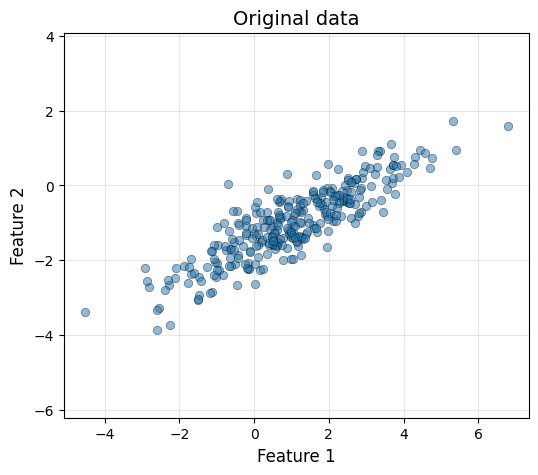

In [4]:
#| code-fold: true
def plot_data(x, y, title=""):
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.5, edgecolors='k', linewidth=0.5)
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    if title:
        plt.title(title, fontsize=14)
    plt.grid(alpha=0.3)
    plt.axis('equal')

plot_data(X[:, 0], X[:, 1], "Original data")

### Fit the PCA to the data

We can fit our PCA to the data.
We will preserve the 2 dimensions to visualize the effect of the change of basis, and drop to 1 dimension further ahead.

In [5]:
pca = PCA()
X_pca_2d = pca.fit_transform(X, 2)

In [6]:
#| code-fold: true
print(f"PC1 captures {pca.explained_variance_ratio[0]:.1%} of the variance")
print(f"PC2 captures {pca.explained_variance_ratio[1]:.1%} of the variance")

PC1 captures 95.2% of the variance
PC2 captures 4.8% of the variance


### Visualize the principal components

Let's draw our PCs over our (centered) data.

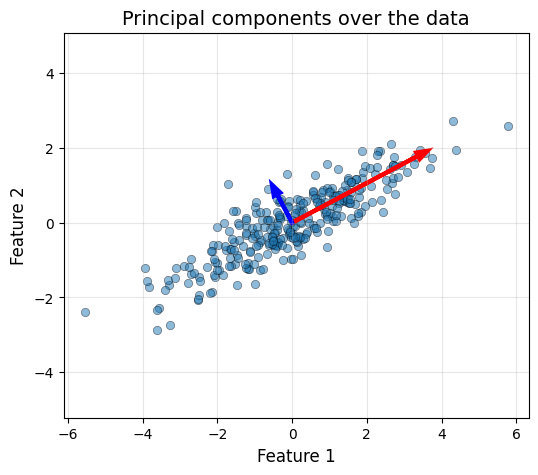

In [7]:
#| code-fold: true
scale = 2
pc1 = pca.eigenvectors[:, 0] * np.sqrt(pca.eigenvalues[0]) * scale
pc2 = pca.eigenvectors[:, 1] * np.sqrt(pca.eigenvalues[1]) * scale

X_centered = X - pca.mean
plot_data(X_centered[:, 0], X_centered[:, 1], "Principal components over the data")
head_width, head_length = 0.2, 0.3
plt.arrow(0, 0, pc1[0], pc1[1], head_width=head_width, head_length=head_length, 
          fc='red', ec='red', linewidth=3)
plt.arrow(0, 0, pc2[0], pc2[1], head_width=head_width, head_length=head_length, 
          fc='blue', ec='blue', linewidth=3)

Now we can also see how the data looks like in the PCA basis, which corresponds to the two arrows in the plot.

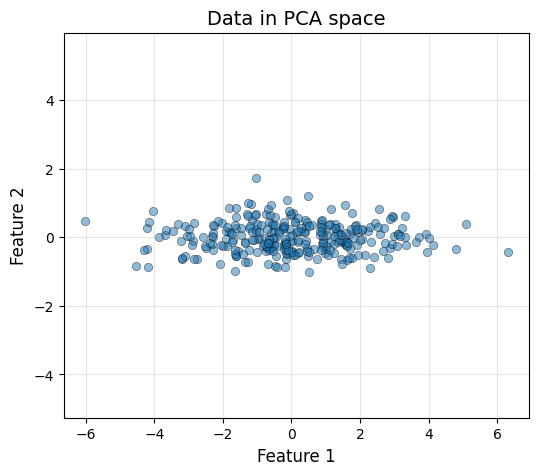

In [8]:
#| code-fold: true
plot_data(X_pca_2d[:, 0], X_pca_2d[:, 1], "Data in PCA space")

The data has been rotated such that the first principal component (x-axis) captures the maximum possible amount of variance, and the second component (y-axis) captures the remaining.
It is interesting to see that this process results in **uncorrelated features**, meaning that $X_{\text{PCA}}$ has a diagonal covariance matrix.

In [9]:
cov_pca = X_pca_2d.T @ X_pca_2d / X_pca_2d.shape[0]
print(f"Covariance matrix in PCA space:\n{np.round(cov_pca, 2)}")
print("Notice the off-diagonal terms are 0!")

Covariance matrix in PCA space:
[[3.63 0.  ]
 [0.   0.18]]
Notice the off-diagonal terms are 0!


### Dimensionality reduction keeping PC1

Now let's drop the less important dimension!

In [10]:
X_pca_1d = pca.fit_transform(X, 1)

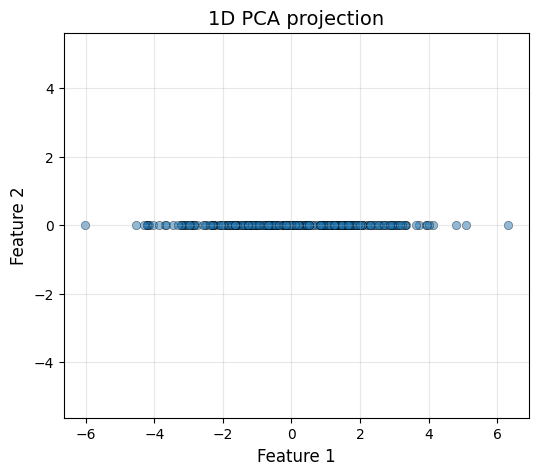

In [11]:
plot_data(X_pca_1d[:, 0], np.zeros_like(X_pca_1d[:, 0]), "1D PCA projection")

### Going back to the original space

The same way that we project our original data to the PCA space, we can apply the inverse linear operation to do the inverse process.
$$X_{\text{PCA}} = X_cV, \, X_c = X_{\text{PCA}}V^T$$
However, the information that has been lost in the process cannot be reocvered.
This means, that we will only be able to obtain the original data if we do not reduce its dimensionality.

In [ ]:
# Reconstruct the data
X_rec_1d = X_pca_1d @ pca.eigenvectors[:, None, 0].T + pca.mean
X_rec_2d = X_pca_2d @ pca.eigenvectors.T + pca.mean

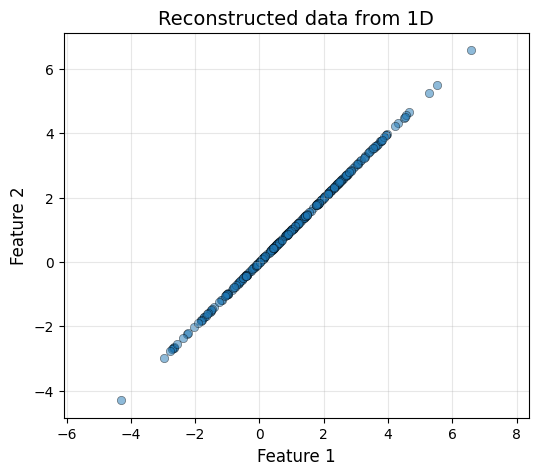

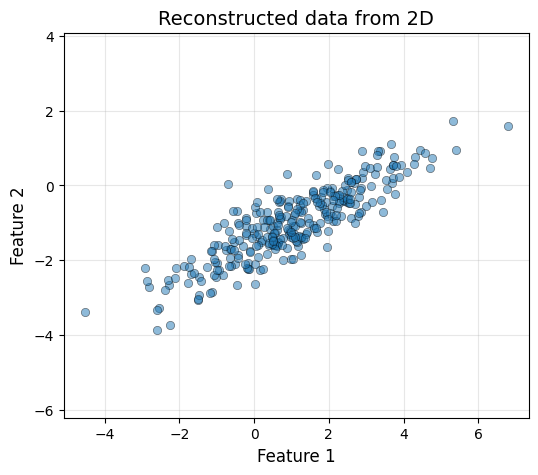

In [22]:
#| code-fold: true
plot_data(X_rec_1d[:, 0], X_rec_1d[:, 0], "Reconstructed data from 1D")
plot_data(X_rec_2d[:, 0], X_rec_2d[:, 1], "Reconstructed data from 2D")